STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.0
  Bin 3: -3.0–-2.5
  Bin 4: -2.5–-2.0
  Bin 5: -2.0–-1.5
  Bin 6: -1.5–-1.0
  Bin 7: -1.0–-0.5
  Bin 8: >-0.5

STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR
  Bin 1: <6.5
  Bin 2: 6.5–7.0
  Bin 3: 7.0–7.5
  Bin 4: 7.5–8.0
  Bin 5: 8.0–8.5
  Bin 6: 8.5–9.0
  Bin 7: 9.0–9.5
  Bin 8: >9.5

STEP 4: Creating combined 2x2 plot (O3N2-M13 only)

Using uniform y-axis range: 8.2 to 8.9

Processing O3N2-M13 calibration for HII r

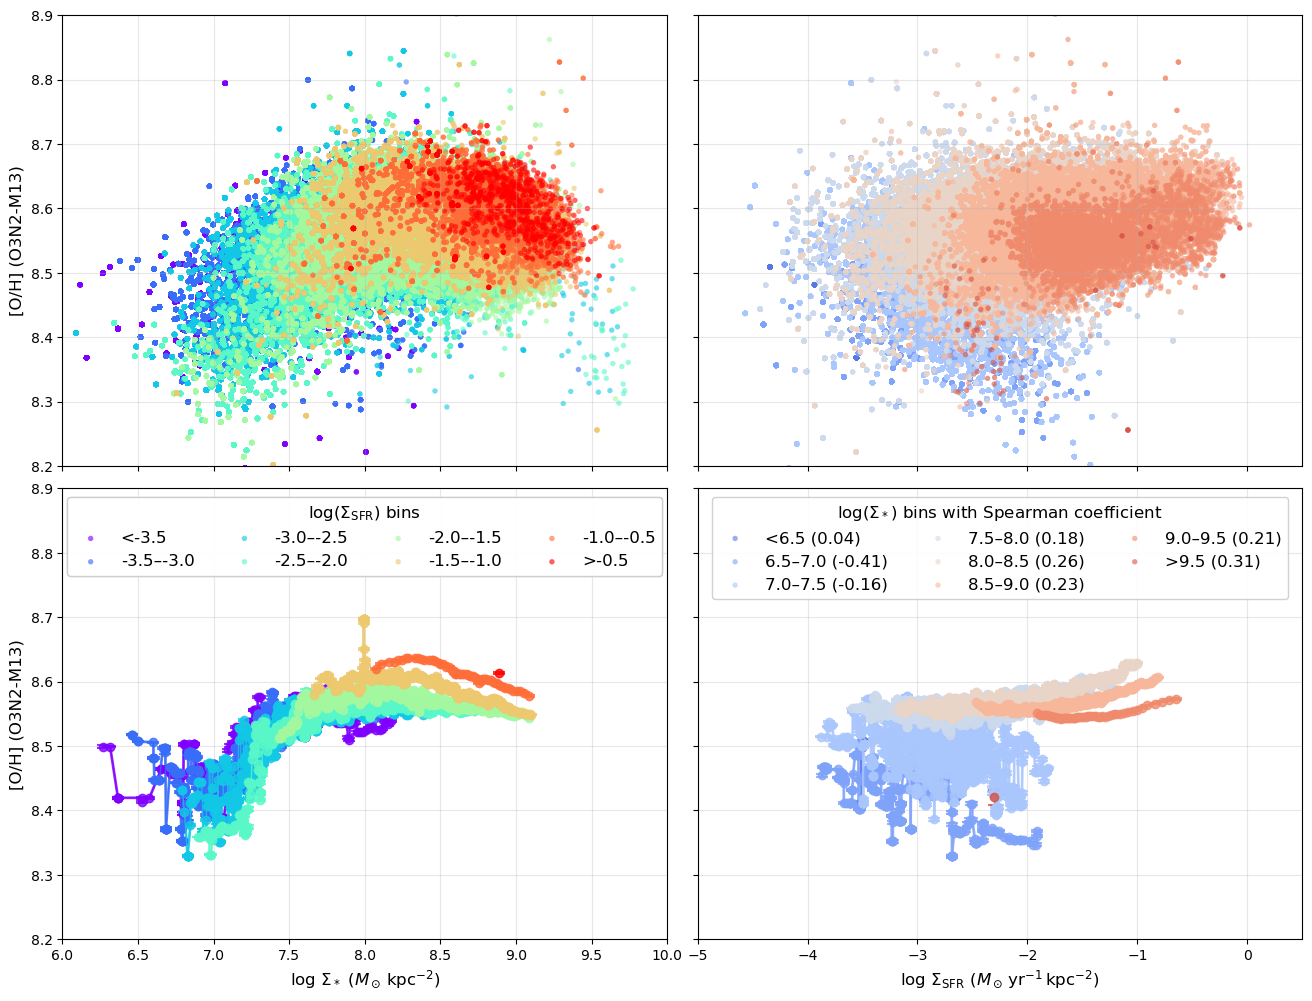


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats
import scipy.ndimage as ndimage
from scipy.optimize import curve_fit

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_running_stats(x_data, y_data, window_size=1000, step_size=100):
    """Calculate running median and std with sliding window (sorted by x)"""
    sort_idx = np.argsort(x_data)
    x_sorted = x_data[sort_idx]
    y_sorted = y_data[sort_idx]
    
    medians, stds, counts, x_centers = [], [], [], []
    n_points = len(x_sorted)
    
    if n_points < window_size:
        if n_points >= 10:
            medians.append(np.median(y_sorted))
            stds.append(np.std(y_sorted))
            counts.append(n_points)
            x_centers.append(np.median(x_sorted))
    else:
        for i in range(0, n_points - window_size + 1, step_size):
            x_window = x_sorted[i : i + window_size]
            y_window = y_sorted[i : i + window_size]
            medians.append(np.median(y_window))
            stds.append(np.std(y_window))
            counts.append(len(y_window))
            x_centers.append(np.median(x_window))
            
    return (np.array(x_centers), np.array(medians), np.array(stds), np.array(counts))

def mzr_model(x, a, b, c):
    return a + b * (x - c) * np.exp(-(x - c))

def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask
    x = x_vals[mask_finite]
    y = y_vals[mask_finite]
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask

def plot_literature_mzr_fits(ax, show_legend=True):
    plot_data = []
    x_sanchez = np.linspace(7.05, 9.15, 200)
    a5, b5, c5 = 8.74, 0.013, 9.50
    y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
    plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
    x_bb = np.linspace(7., 8.9, 200)
    a2, b2, c2 = 8.55, 0.014, 9.14
    y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
    plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
    x_ef = np.linspace(6.5, 10.0, 200)
    a4, b4, c4 = 8.61, 0.008, 10.0
    y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
    plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
    for x, y, label, linestyle, color in plot_data:
        ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
excluded_galaxies = {'NGC4383'}
included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

print("\n" + "="*80)
print("STEP 2: Defining 8 SFR bins for rMZR")
print("="*80)
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

print("\n" + "="*80)
print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
print("="*80)
n_bins_sigmaM = 8
sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)
x_range_Zgas = (-5.0, 0.5)
print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
plt.subplots_adjust(wspace=0.05, hspace=0.05)
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'
print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
legend_handles_sfr, legend_labels_sfr = [], []
valid_bins_rMZR = 0
for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    print(f"  Bin {bin_labels[i]}: {n_pixels_HII} pixels")
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaM_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sfr.append(scatter_hii)
        legend_labels_sfr.append(bin_labels[i])
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        if len(x_bin) >= 10:
            mass_centers_HII, medians_HII, stds_HII, counts_HII = calculate_running_stats(x_bin, y_bin, window_size=1000, step_size=100)
            if len(mass_centers_HII) > 0:
                sem_HII = stds_HII / np.sqrt(counts_HII)
                ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=sem_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                if len(mass_centers_HII) > 1:
                    ax_rMZR_median.plot(mass_centers_HII, medians_HII, color=colors_sfr[i], linewidth=2, alpha=0.8)
                valid_bins_rMZR += 1

ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(*x_range_rMZR)
ax_rMZR_scatter.set_ylim(common_ylim)
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(*x_range_rMZR)
ax_rMZR_median.set_ylim(common_ylim)
legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR})$ bins', title_fontsize=12)
ax_rMZR_median.add_artist(legend1)
print(f"  rMZR valid bins: {valid_bins_rMZR}")

print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    print(f"  Bin {bin_labels_sigmaM[i]}: {n_pixels_HII} pixels")
    if n_pixels_HII >= 10:
        x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
        y_bin_all = oh_data_HII[in_bin_HII]
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
        legend_handles_sigmaM.append(scatter_hii)
        mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
        x_bin = x_bin_all[mask_95_bin]
        y_bin = y_bin_all[mask_95_bin]
        spearman_text = "N/A"
        if len(x_bin) > 1:
            y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
            x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
            mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
            x_clipped = x_bin[mask_clip]
            y_clipped = y_bin[mask_clip]
            sfr_centers_HII, medians_HII, stds_HII, counts_HII = calculate_running_stats(x_clipped, y_clipped, window_size=1000, step_size=100)
            if len(sfr_centers_HII) > 0:
                if len(x_clipped) > 10:
                    corr, _ = stats.spearmanr(x_clipped, y_clipped)
                    spearman_text = f"{corr:.2f}"
                sem_HII = stds_HII / np.sqrt(counts_HII)
                ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=sem_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                if len(sfr_centers_HII) > 1:
                    ax_Zgas_median.plot(sfr_centers_HII, medians_HII, color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                valid_bins_Zgas += 1
        legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")

ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(*x_range_Zgas)
ax_Zgas_scatter.set_ylim(common_ylim)
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(*x_range_Zgas)
ax_Zgas_median.set_ylim(common_ylim)
ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*)$ bins with Spearman coefficient', title_fontsize=12)
print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.png', dpi=600, bbox_inches='tight')
# plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

Plotting rMZR running-median trends (ONLY bottom-left panel)
NOTE: Running medians are computed using points inside the 95% density contour (per Σ_SFR bin).
  Bin <-3.5: 21855 pixels
  Bin -3.5–-3.0: 86651 pixels
  Bin -3.0–-2.5: 199302 pixels
  Bin -2.5–-2.0: 249627 pixels
  Bin -2.0–-1.5: 165795 pixels
  Bin -1.5–-1.0: 50522 pixels
  Bin -1.0–-0.5: 7113 pixels
  Bin >-0.5: 1016 pixels

  rMZR valid bins plotted: 8


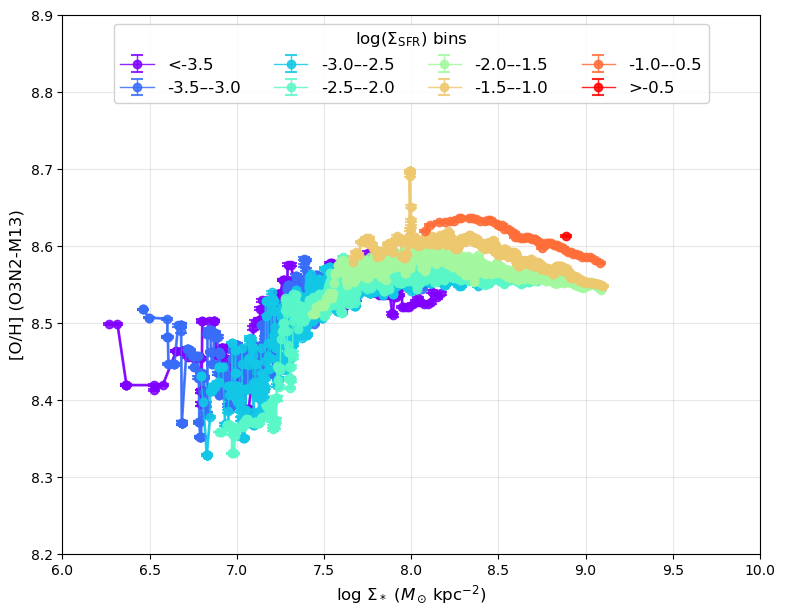


COMPLETED: rMZR running-median trends (O3N2-M13 only)
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383
Shared y-range: 8.2 to 8.9


In [2]:
# ------------------------------------------------------------------
# rMZR running-median trends (HII regions only)
# Using O3N2-M13 indicator only
# This cell shows ONLY the former bottom-left panel.
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.ndimage as ndimage


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)


def calculate_running_stats(x_data, y_data, window_size=1000, step_size=100):
    """Calculate running median and std with sliding window (sorted by x)."""
    sort_idx = np.argsort(x_data)
    x_sorted = x_data[sort_idx]
    y_sorted = y_data[sort_idx]

    medians, stds, counts, x_centers = [], [], [], []
    n_points = len(x_sorted)

    if n_points < window_size:
        if n_points >= 10:
            medians.append(np.median(y_sorted))
            stds.append(np.std(y_sorted))
            counts.append(n_points)
            x_centers.append(np.median(x_sorted))
    else:
        for i in range(0, n_points - window_size + 1, step_size):
            x_window = x_sorted[i : i + window_size]
            y_window = y_sorted[i : i + window_size]
            medians.append(np.median(y_window))
            stds.append(np.std(y_window))
            counts.append(len(y_window))
            x_centers.append(np.median(x_window))

    return (np.array(x_centers), np.array(medians), np.array(stds), np.array(counts))


def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        return (empty_mask, None, None) if return_contour else empty_mask

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]

    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]

    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)

    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local

    if return_contour:
        return full_mask, level_95, (X, Y, H_smooth)
    return full_mask


# ----------------------------
# STEP 1: Collect data
# ----------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}

included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("=" * 80)
print("Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (
            np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
        )
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")


# ----------------------------
# STEP 2: Define Σ_SFR bins
# ----------------------------
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ["<-3.5", "-3.5–-3.0", "-3.0–-2.5", "-2.5–-2.0", "-2.0–-1.5", "-1.5–-1.0", "-1.0–-0.5", ">-0.5"]
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))


# ----------------------------
# STEP 3: Plot ONLY rMZR medians
# ----------------------------
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)

print("\n" + "=" * 80)
print("Plotting rMZR running-median trends (ONLY bottom-left panel)")
print("NOTE: Running medians are computed using points inside the 95% density contour (per Σ_SFR bin).")
print("=" * 80)

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

legend_handles, legend_labels = [], []
valid_bins_rMZR = 0

for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = np.sum(in_bin_HII)
    print(f"  Bin {bin_labels[i]}: {n_pixels_HII} pixels")

    if n_pixels_HII < 10:
        continue

    x_bin_all = all_logSigmaM_HII[in_bin_HII]
    y_bin_all = all_oh_o3n2_m13_HII[in_bin_HII]

    mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
    x_bin = x_bin_all[mask_95_bin]
    y_bin = y_bin_all[mask_95_bin]

    if len(x_bin) < 10:
        continue

    mass_centers_HII, medians_HII, stds_HII, counts_HII = calculate_running_stats(
        x_bin, y_bin, window_size=1000, step_size=100
    )
    if len(mass_centers_HII) == 0:
        continue

    sem_HII = stds_HII / np.sqrt(counts_HII)

    eb = ax.errorbar(
        mass_centers_HII,
        medians_HII,
        yerr=sem_HII,
        color=colors_sfr[i],
        marker="o",
        markersize=6,
        linewidth=1,
        capsize=4,
        capthick=1.5,
        alpha=0.85,
    )

    if len(mass_centers_HII) > 1:
        ax.plot(mass_centers_HII, medians_HII, color=colors_sfr[i], linewidth=2, alpha=0.85)

    legend_handles.append(eb)
    legend_labels.append(bin_labels[i])
    valid_bins_rMZR += 1

ax.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax.set_ylabel(r"[O/H] (O3N2-M13)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(*x_range_rMZR)
ax.set_ylim(common_ylim)

ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    ncol=4,
    fontsize=12,
    framealpha=0.9,
    title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
    title_fontsize=12,
)

print(f"\n  rMZR valid bins plotted: {valid_bins_rMZR}")
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: rMZR running-median trends (O3N2-M13 only)")
print("=" * 80)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print(f"Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

Plotting rMZR running-median trends
NOTE: Running medians are computed after 3σ clipping (in both x and y) within each Σ_SFR bin.
  Bin <-3.5: 21855 → 21674 kept after 3σ clip (0.992)
  Bin -3.5–-3.0: 86651 → 86484 kept after 3σ clip (0.998)
  Bin -3.0–-2.5: 199302 → 196472 kept after 3σ clip (0.986)
  Bin -2.5–-2.0: 249627 → 242873 kept after 3σ clip (0.973)
  Bin -2.0–-1.5: 165795 → 162342 kept after 3σ clip (0.979)
  Bin -1.5–-1.0: 50522 → 49911 kept after 3σ clip (0.988)
  Bin -1.0–-0.5: 7113 → 7051 kept after 3σ clip (0.991)
  Bin >-0.5: 1016 → 995 kept af

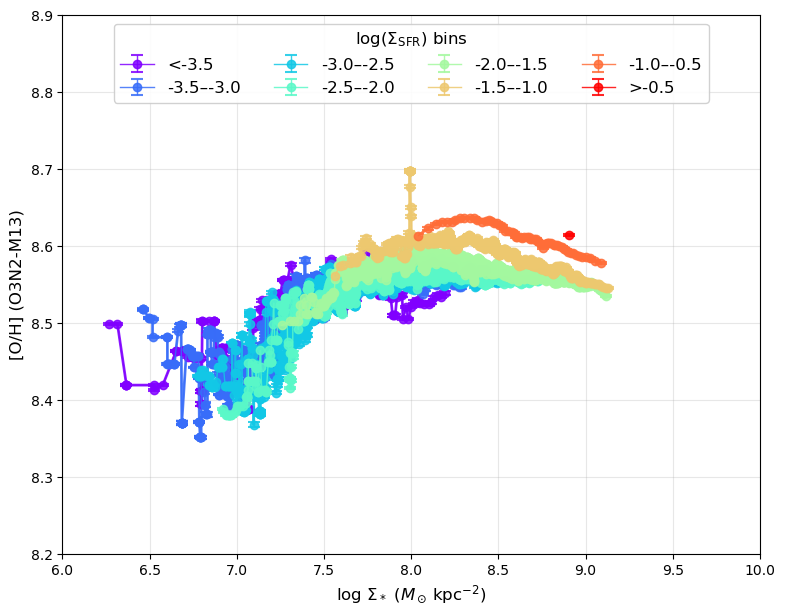


COMPLETED: rMZR running-median trends (O3N2-M13 only, 3σ clip)
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383
Shared y-range: 8.2 to 8.9


In [3]:
# ------------------------------------------------------------------
# rMZR running-median trends (HII regions only)
# Using O3N2-M13 indicator only
# This cell uses 3-sigma clipping (per Σ_SFR bin) instead of 95% contour.
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)


def calculate_running_stats(x_data, y_data, window_size=1000, step_size=100):
    """Calculate running median and std with sliding window (sorted by x)."""
    sort_idx = np.argsort(x_data)
    x_sorted = x_data[sort_idx]
    y_sorted = y_data[sort_idx]

    medians, stds, counts, x_centers = [], [], [], []
    n_points = len(x_sorted)

    if n_points < window_size:
        if n_points >= 10:
            medians.append(np.median(y_sorted))
            stds.append(np.std(y_sorted))
            counts.append(n_points)
            x_centers.append(np.median(x_sorted))
    else:
        for i in range(0, n_points - window_size + 1, step_size):
            x_window = x_sorted[i : i + window_size]
            y_window = y_sorted[i : i + window_size]
            medians.append(np.median(y_window))
            stds.append(np.std(y_window))
            counts.append(len(y_window))
            x_centers.append(np.median(x_window))

    return (np.array(x_centers), np.array(medians), np.array(stds), np.array(counts))


def sigma_clip_xy(x, y, nsigma=3.0):
    """3-sigma clip in both x and y (finite-only), returning clipped arrays."""
    mask_finite = np.isfinite(x) & np.isfinite(y)
    if not np.any(mask_finite):
        return x[:0], y[:0]

    x_f = x[mask_finite]
    y_f = y[mask_finite]

    x_mean = np.nanmean(x_f)
    y_mean = np.nanmean(y_f)
    x_std = np.nanstd(x_f)
    y_std = np.nanstd(y_f)

    mask = np.ones_like(x_f, dtype=bool)
    if np.isfinite(x_std) and x_std > 0:
        mask &= np.abs(x_f - x_mean) < nsigma * x_std
    if np.isfinite(y_std) and y_std > 0:
        mask &= np.abs(y_f - y_mean) < nsigma * y_std

    return x_f[mask], y_f[mask]


# ----------------------------
# STEP 1: Collect data
# ----------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}

included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("=" * 80)
print("Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (
            np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
        )
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")


# ----------------------------
# STEP 2: Define Σ_SFR bins
# ----------------------------
n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ["<-3.5", "-3.5–-3.0", "-3.0–-2.5", "-2.5–-2.0", "-2.0–-1.5", "-1.5–-1.0", "-1.0–-0.5", ">-0.5"]
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))


# ----------------------------
# STEP 3: Plot rMZR medians after 3σ clipping
# ----------------------------
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)

print("\n" + "=" * 80)
print("Plotting rMZR running-median trends")
print("NOTE: Running medians are computed after 3σ clipping (in both x and y) within each Σ_SFR bin.")
print("=" * 80)

fig, ax = plt.subplots(1, 1, figsize=(9, 7))

legend_handles, legend_labels = [], []
valid_bins_rMZR = 0

for i in range(n_bins):
    in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pixels_HII = int(np.sum(in_bin_HII))

    if n_pixels_HII < 10:
        print(f"  Bin {bin_labels[i]}: {n_pixels_HII} pixels (skip)")
        continue

    x_bin_all = all_logSigmaM_HII[in_bin_HII]
    y_bin_all = all_oh_o3n2_m13_HII[in_bin_HII]

    x_clipped, y_clipped = sigma_clip_xy(x_bin_all, y_bin_all, nsigma=3.0)

    kept = len(x_clipped)
    frac_kept = kept / n_pixels_HII if n_pixels_HII > 0 else 0.0
    print(f"  Bin {bin_labels[i]}: {n_pixels_HII} → {kept} kept after 3σ clip ({frac_kept:.3f})")

    if kept < 10:
        continue

    mass_centers_HII, medians_HII, stds_HII, counts_HII = calculate_running_stats(
        x_clipped, y_clipped, window_size=1000, step_size=100
    )
    if len(mass_centers_HII) == 0:
        continue

    sem_HII = stds_HII / np.sqrt(counts_HII)

    eb = ax.errorbar(
        mass_centers_HII,
        medians_HII,
        yerr=sem_HII,
        color=colors_sfr[i],
        marker="o",
        markersize=6,
        linewidth=1,
        capsize=4,
        capthick=1.5,
        alpha=0.85,
    )

    if len(mass_centers_HII) > 1:
        ax.plot(mass_centers_HII, medians_HII, color=colors_sfr[i], linewidth=2, alpha=0.85)

    legend_handles.append(eb)
    legend_labels.append(bin_labels[i])
    valid_bins_rMZR += 1

ax.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax.set_ylabel(r"[O/H] (O3N2-M13)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(*x_range_rMZR)
ax.set_ylim(common_ylim)

ax.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    ncol=4,
    fontsize=12,
    framealpha=0.9,
    title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
    title_fontsize=12,
)

print(f"\n  rMZR valid bins plotted: {valid_bins_rMZR}")
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: rMZR running-median trends (O3N2-M13 only, 3σ clip)")
print("=" * 80)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print(f"Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


  NGC4383: excluded from analysis
Total combined pixels (HII): 781881

Precomputing 95% contour masks per Σ_SFR bin...
  Bin <-3.5: 21855 → 21340 after 95% contour
  Bin -3.5–-3.0: 86651 → 83927 after 95% contour
  Bin -3.0–-2.5: 199302 → 192193 after 95% contour
  Bin -2.5–-2.0: 249627 → 240161 after 95% contour
  Bin -2.0–-1.5: 165795 → 158587 after 95% contour
  Bin -1.5–-1.0: 50522 → 48642 after 95% contour
  Bin -1.0–-0.5: 7113 → 6914 after 95% contour
  Bin >-0.5: 1016 → 1001 after 95% contour

Plotting 6×4 grid of running-median configurations...


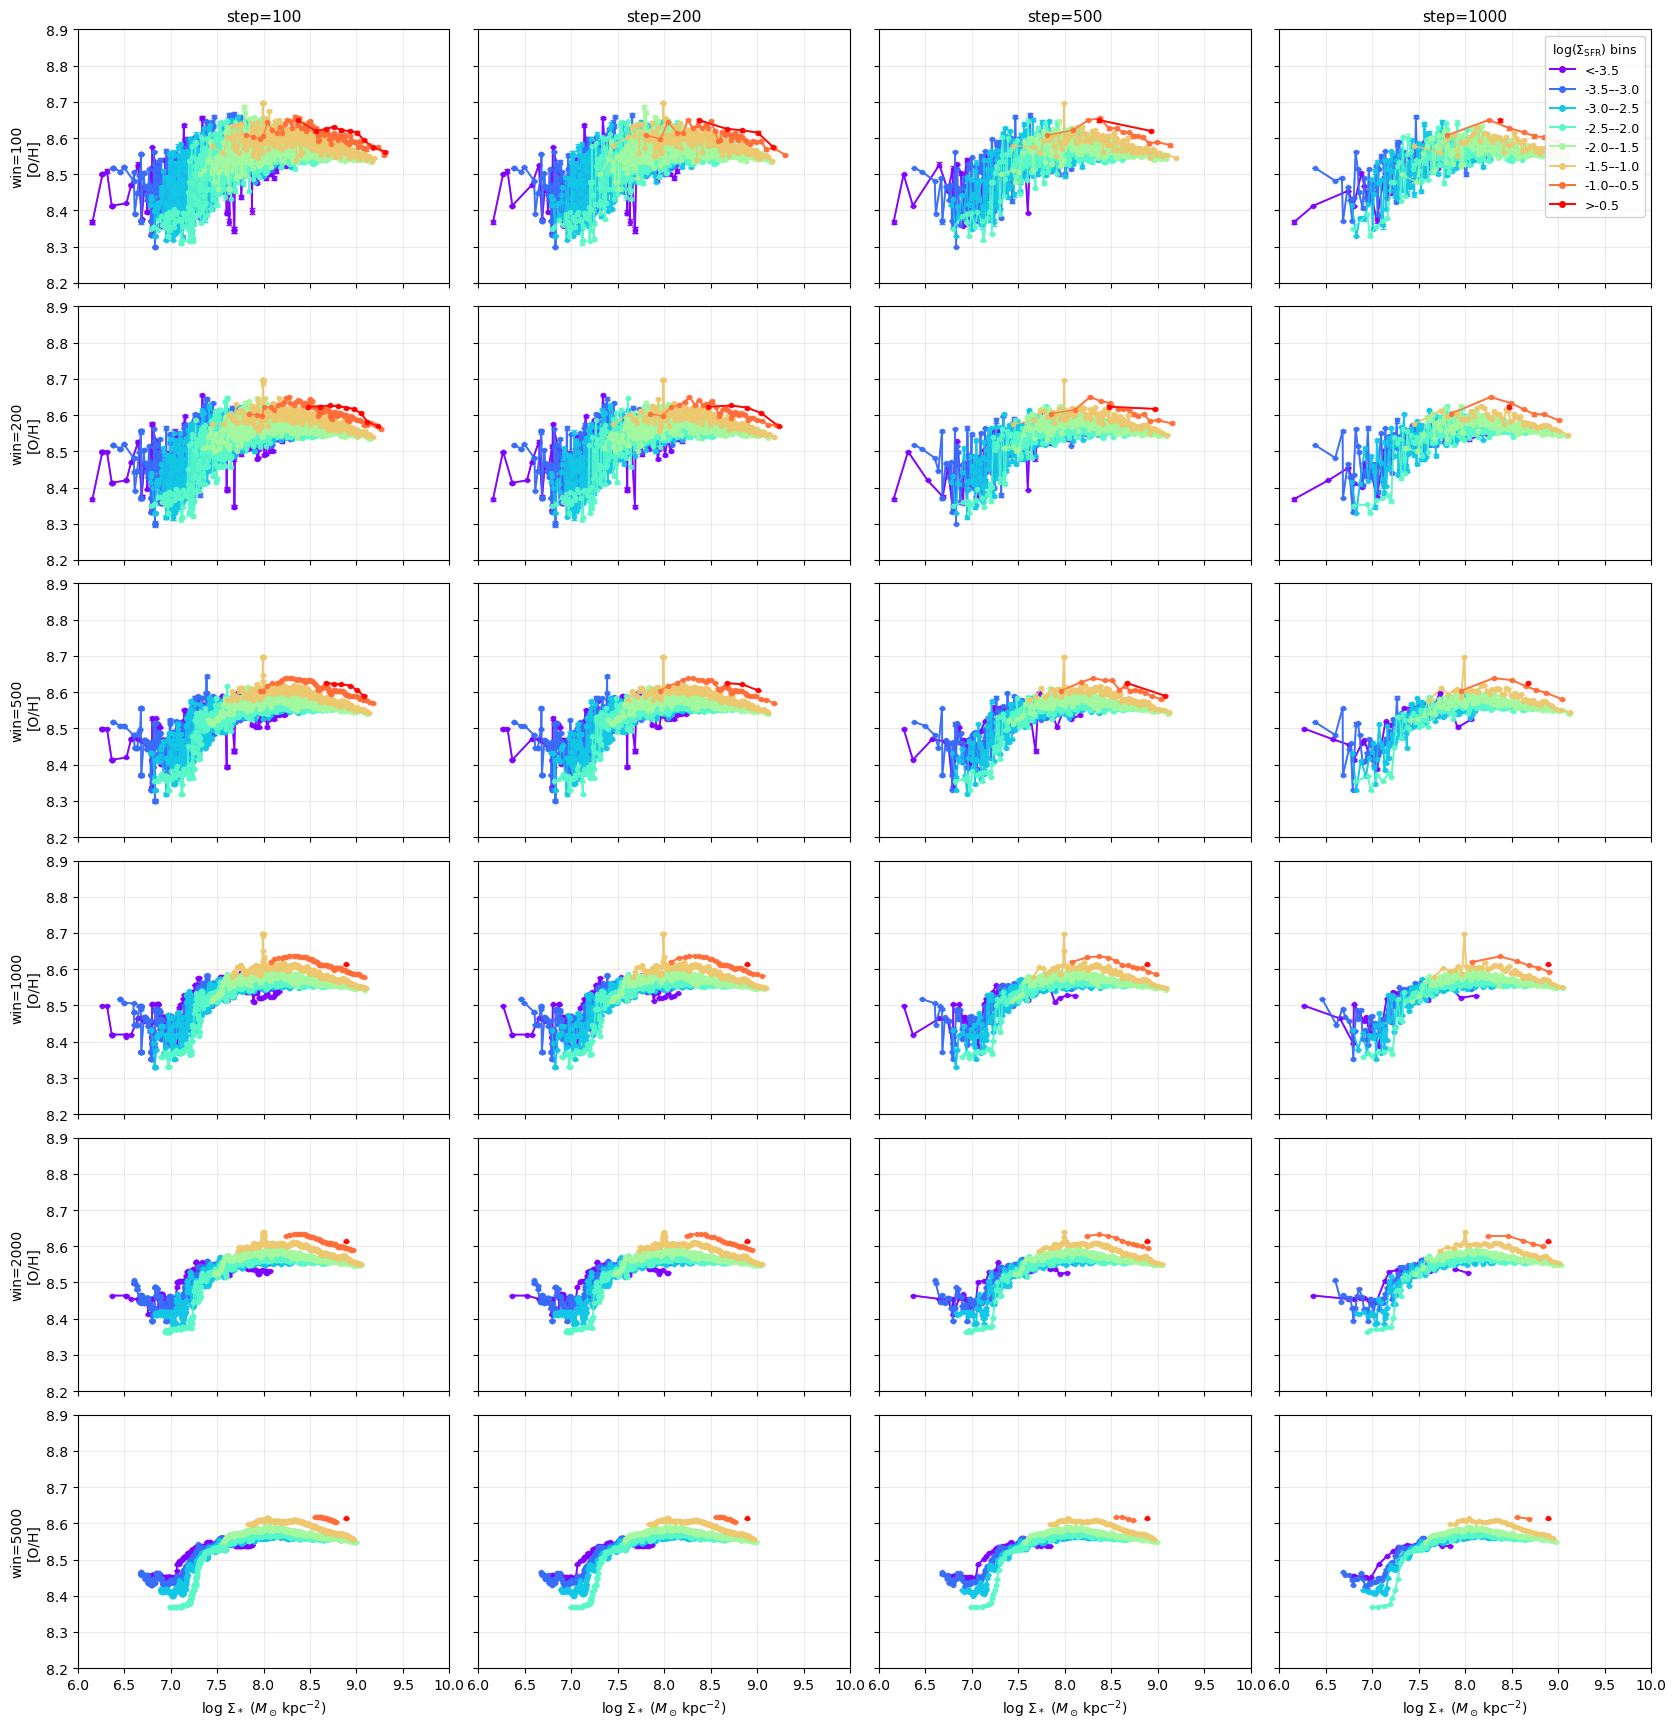


COMPLETED: 6×4 grid of rMZR running-median configurations
Rows window_size: [100, 200, 500, 1000, 2000, 5000]
Cols step_size: [100, 200, 500, 1000]
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383
Shared y-range: 8.2 to 8.9


In [4]:
# ------------------------------------------------------------------
# rMZR running-median trends (HII regions only) — grid of window/step
# Using O3N2-M13 indicator only
# 6 rows × 4 columns:
#   rows:    window_size = 100, 200, 500, 1000, 2000, 5000
#   columns: step_size   = 100, 200, 500, 1000
# Filtering: same as the original bottom-left panel (95% density contour per bin)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.ndimage as ndimage
import bottleneck as bn
from matplotlib.lines import Line2D


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)


def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0):
    """Return mask for points inside the 95% density contour within given ranges."""
    mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
    if not np.any(mask_finite):
        return np.zeros_like(x_vals, dtype=bool)

    x = x_vals[mask_finite]
    y = y_vals[mask_finite]

    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
    H_smooth = ndimage.gaussian_filter(H, sigma=sigma)

    H_flat = np.sort(H_smooth.ravel())[::-1]
    H_cumsum = np.cumsum(H_flat)
    level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
    level_95 = H_flat[level_idx]

    dx = (x_range[1] - x_range[0]) / nbins
    dy = (y_range[1] - y_range[0]) / nbins
    x_idx = (x - x_range[0]) / dx - 0.5
    y_idx = (y - y_range[0]) / dy - 0.5
    densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode="constant", cval=0.0)

    mask_local = densities >= level_95
    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_finite)[0]] = mask_local
    return full_mask


def running_stats_sorted(x_sorted, y_sorted, window_size, step_size, min_points=10):
    """Running median/std on arrays already sorted by x.

    Uses Bottleneck for speed. Windows are defined in index-space (point-count),
    consistent with the earlier implementation.
    """
    n = len(x_sorted)

    if n < window_size:
        if n >= min_points:
            x_center = np.median(x_sorted)
            y_med = np.median(y_sorted)
            y_std = np.std(y_sorted)
            return (
                np.array([x_center]),
                np.array([y_med]),
                np.array([y_std]),
                np.array([n]),
            )
        return (np.array([]), np.array([]), np.array([]), np.array([]))

    # trailing window statistics aligned to end index
    y_med_all = bn.move_median(y_sorted, window=window_size, min_count=min_points)
    y_std_all = bn.move_std(y_sorted, window=window_size, min_count=min_points)

    end_indices = np.arange(window_size - 1, n, step_size)

    # x-center is the median of the x-window (exact for sorted x)
    if window_size % 2 == 1:
        center_offset = window_size // 2
        x_centers = x_sorted[end_indices - (window_size - 1) + center_offset]
    else:
        center_left = window_size // 2 - 1
        center_right = window_size // 2
        start_indices = end_indices - (window_size - 1)
        x_centers = 0.5 * (
            x_sorted[start_indices + center_left] + x_sorted[start_indices + center_right]
        )

    medians = y_med_all[end_indices]
    stds = y_std_all[end_indices]
    counts = np.full_like(end_indices, window_size, dtype=int)

    # drop NaNs from min_count padding (should only affect the very beginning)
    ok = np.isfinite(medians) & np.isfinite(stds)
    return (x_centers[ok], medians[ok], stds[ok], counts[ok])


# ----------------------------
# STEP 1: Collect data
# ----------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}

included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("=" * 80)
print("Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (
            np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
        )
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.asarray(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.asarray(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.asarray(all_oh_o3n2_m13_HII)

print(f"Total combined pixels (HII): {len(all_logSigmaM_HII)}")


# ----------------------------
# STEP 2: Define bins, ranges
# ----------------------------
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)

n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ["<-3.5", "-3.5–-3.0", "-3.0–-2.5", "-2.5–-2.0", "-2.0–-1.5", "-1.5–-1.0", "-1.0–-0.5", ">-0.5"]
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

window_sizes = [100, 200, 500, 1000, 2000, 5000]
step_sizes = [100, 200, 500, 1000]


# ----------------------------
# STEP 3: Precompute per-bin (95% contour) + sorting
# ----------------------------
print("\n" + "=" * 80)
print("Precomputing 95% contour masks per Σ_SFR bin...")
print("=" * 80)

bin_sorted = []  # list of (x_sorted, y_sorted) or None
bin_counts = []

for i in range(n_bins):
    in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pix = int(np.sum(in_bin))
    bin_counts.append(n_pix)

    if n_pix < 10:
        bin_sorted.append(None)
        print(f"  Bin {bin_labels[i]}: {n_pix} (skip)")
        continue

    x_all = all_logSigmaM_HII[in_bin]
    y_all = all_oh_o3n2_m13_HII[in_bin]

    mask_95 = compute_density_mask(x_all, y_all, x_range_rMZR, common_ylim)
    x_f = x_all[mask_95]
    y_f = y_all[mask_95]

    if len(x_f) < 10:
        bin_sorted.append(None)
        print(f"  Bin {bin_labels[i]}: {n_pix} → {len(x_f)} after 95% contour (skip)")
        continue

    sort_idx = np.argsort(x_f)
    x_sorted = x_f[sort_idx]
    y_sorted = y_f[sort_idx]

    bin_sorted.append((x_sorted, y_sorted))
    print(f"  Bin {bin_labels[i]}: {n_pix} → {len(x_f)} after 95% contour")


# ----------------------------
# STEP 4: Grid plot
# ----------------------------
print("\n" + "=" * 80)
print("Plotting 6×4 grid of running-median configurations...")
print("=" * 80)

fig, axes = plt.subplots(
    nrows=len(window_sizes),
    ncols=len(step_sizes),
    figsize=(4.2 * len(step_sizes), 2.9 * len(window_sizes)),
    sharex=True,
    sharey=True,
)

for r, window_size in enumerate(window_sizes):
    for c, step_size in enumerate(step_sizes):
        ax = axes[r, c]

        for i in range(n_bins):
            if bin_sorted[i] is None:
                continue

            x_sorted, y_sorted = bin_sorted[i]
            x_cent, meds, stds, counts = running_stats_sorted(
                x_sorted,
                y_sorted,
                window_size=window_size,
                step_size=step_size,
                min_points=10,
            )
            if len(x_cent) == 0:
                continue

            sem = stds / np.sqrt(counts)
            ax.errorbar(
                x_cent,
                meds,
                yerr=sem,
                color=colors_sfr[i],
                marker="o",
                markersize=3,
                linewidth=1,
                capsize=2,
                capthick=1,
                alpha=0.85,
            )
            if len(x_cent) > 1:
                ax.plot(x_cent, meds, color=colors_sfr[i], linewidth=1.4, alpha=0.85)

        ax.grid(True, alpha=0.25)
        ax.set_xlim(*x_range_rMZR)
        ax.set_ylim(common_ylim)

        if r == 0:
            ax.set_title(f"step={step_size}", fontsize=11)
        if c == 0:
            ax.set_ylabel(f"win={window_size}\n[O/H]", fontsize=10)
        if r == len(window_sizes) - 1:
            ax.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=10)

# Legend proxies (so we can place legend on a different subplot)
legend_proxies = [
    Line2D([0], [0], color=colors_sfr[i], marker="o", linestyle="-", linewidth=1.4, markersize=4)
    for i in range(n_bins)
]
legend_ax = axes[0, -1]  # top-right panel
legend_ax.legend(
    legend_proxies,
    bin_labels,
    loc="upper right",
    fontsize=9,
    framealpha=0.9,
    title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
    title_fontsize=9,
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: 6×4 grid of rMZR running-median configurations")
print("=" * 80)
print("Rows window_size:", window_sizes)
print("Cols step_size:", step_sizes)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print(f"Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


  NGC4383: excluded from analysis
Total combined pixels (HII): 781881

Precomputing 3σ-clip masks per Σ_SFR bin...
  Bin <-3.5: 21855 → 21663 after 3σ clip
  Bin -3.5–-3.0: 86651 → 86484 after 3σ clip
  Bin -3.0–-2.5: 199302 → 196472 after 3σ clip
  Bin -2.5–-2.0: 249627 → 242869 after 3σ clip
  Bin -2.0–-1.5: 165795 → 162328 after 3σ clip
  Bin -1.5–-1.0: 50522 → 49911 after 3σ clip
  Bin -1.0–-0.5: 7113 → 7051 after 3σ clip
  Bin >-0.5: 1016 → 995 after 3σ clip

Plotting 6×4 grid of running-median configurations...


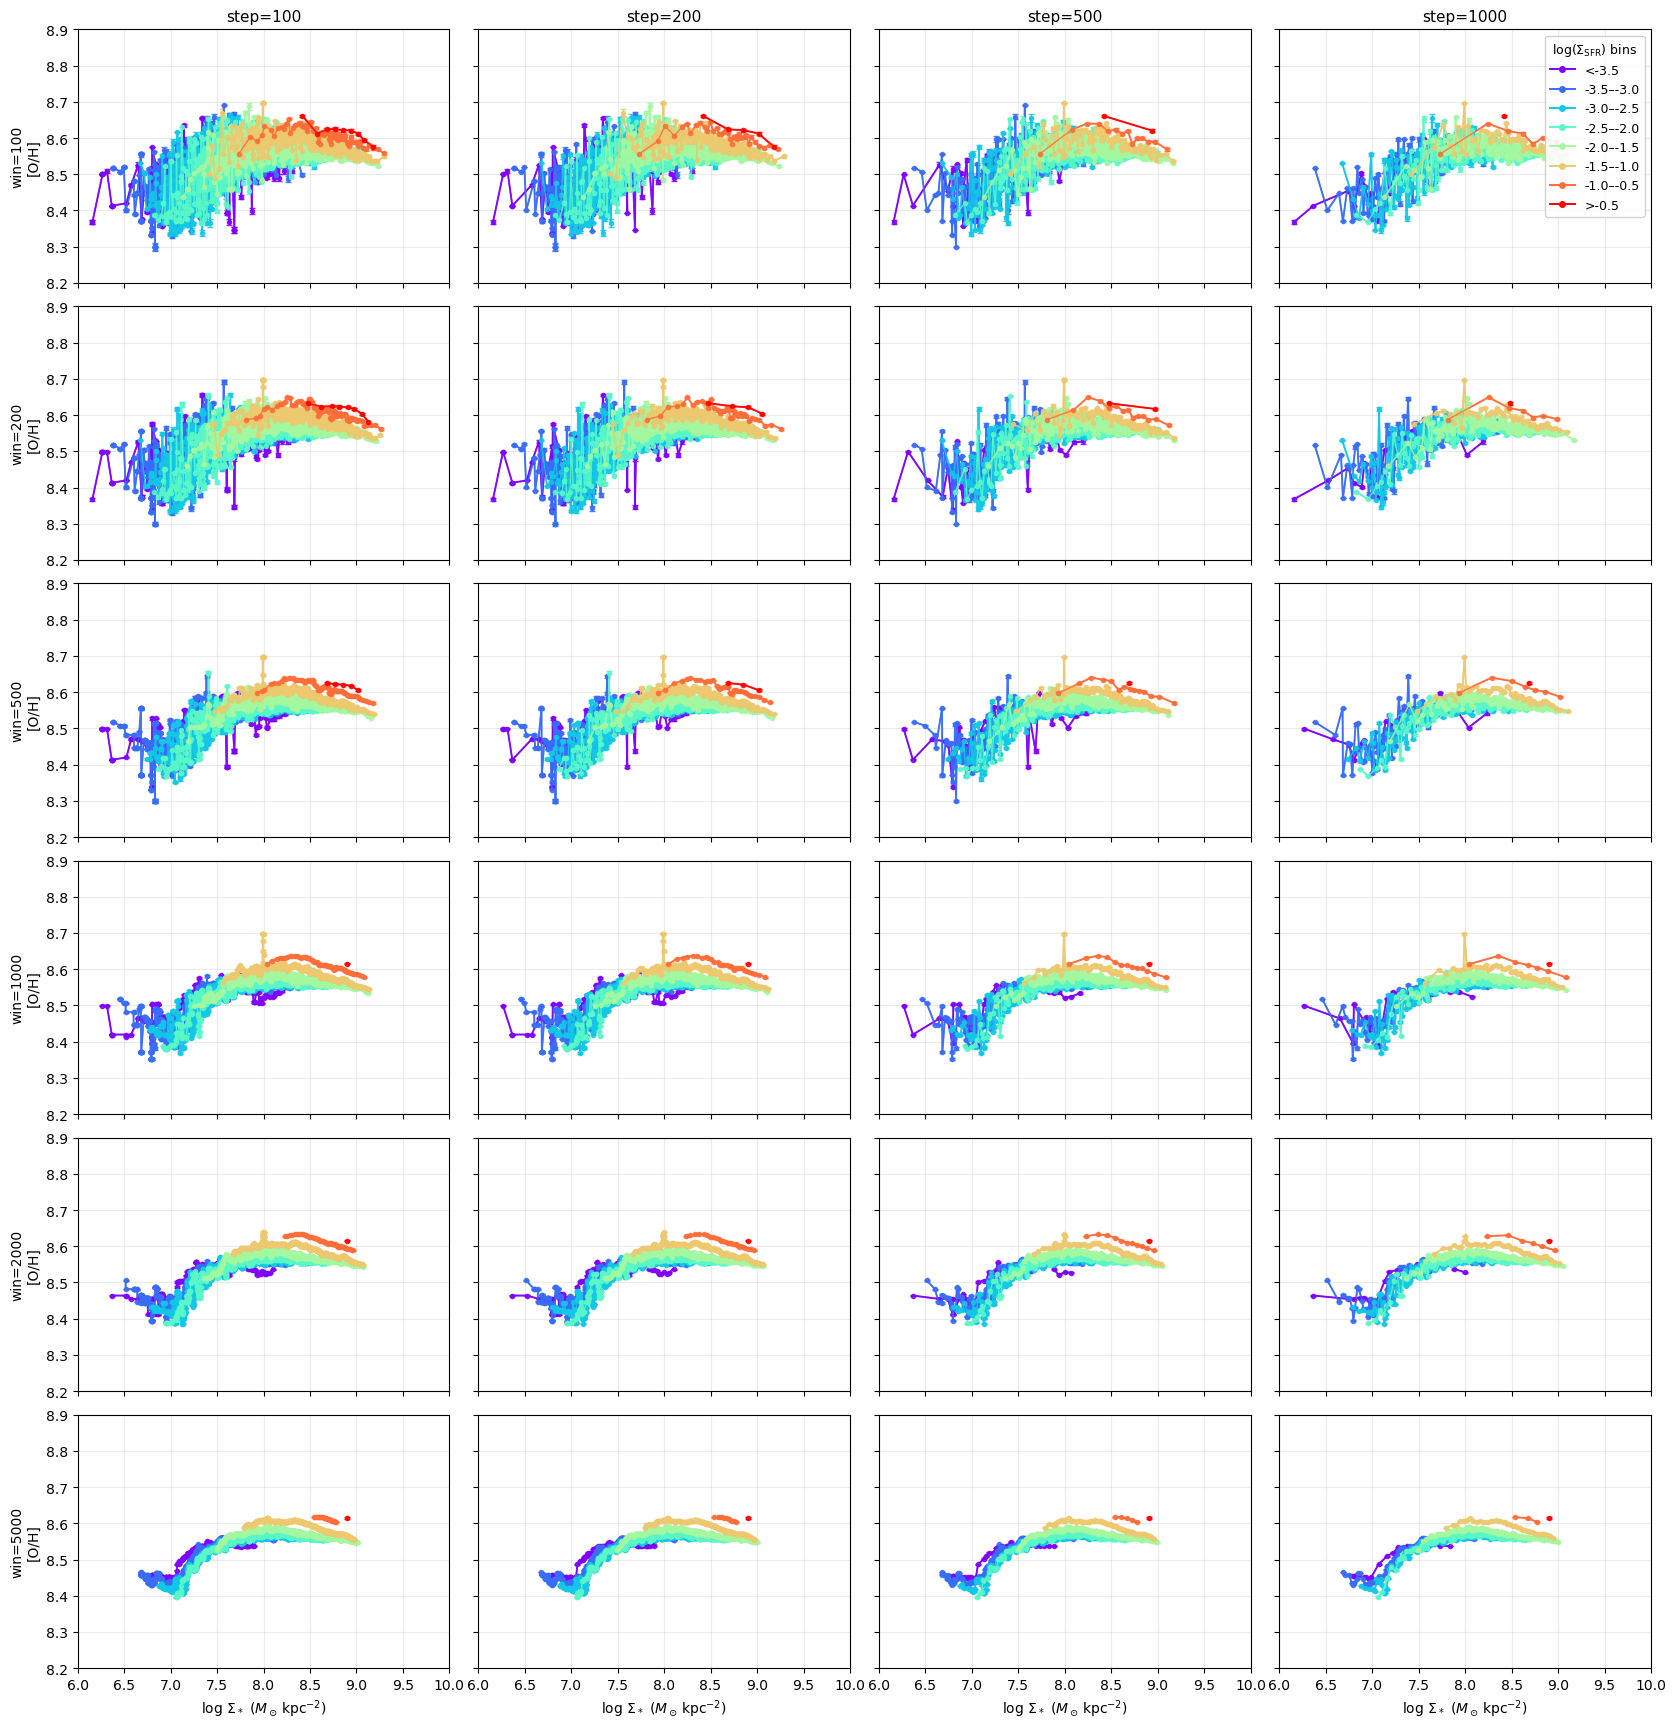


COMPLETED: 6×4 grid of rMZR running-median configurations
Rows window_size: [100, 200, 500, 1000, 2000, 5000]
Cols step_size: [100, 200, 500, 1000]
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383
Shared y-range: 8.2 to 8.9


In [5]:
# ------------------------------------------------------------------
# rMZR running-median trends (HII regions only) — grid of window/step
# Using O3N2-M13 indicator only
# 6 rows × 4 columns:
#   rows:    window_size = 100, 200, 500, 1000, 2000, 5000
#   columns: step_size   = 100, 200, 500, 1000
# Filtering: per-bin 3σ clipping (in both x and y) within the plot ranges
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import bottleneck as bn
from matplotlib.lines import Line2D


def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h:
        sigM = h["LOGMASS_SURFACE_DENSITY"].data
    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h:
        sigSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
        oh_o3n2_m13_HII = h["O_H_O3N2_M13_HII"].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)


def sigma_clip_xy(x_vals, y_vals, x_range, y_range, sigma=3.0, min_points=10):
    """Return mask for points that pass a single-pass 3σ clip in both x and y.

    The clip is computed on points within the plot ranges to keep behavior
    comparable to the previous range-limited contour filtering.
    """
    mask_base = (
        np.isfinite(x_vals)
        & np.isfinite(y_vals)
        & (x_vals >= x_range[0])
        & (x_vals <= x_range[1])
        & (y_vals >= y_range[0])
        & (y_vals <= y_range[1])
    )
    if int(np.sum(mask_base)) < min_points:
        return np.zeros_like(x_vals, dtype=bool)

    x = x_vals[mask_base]
    y = y_vals[mask_base]

    x_mean = np.mean(x)
    x_std = np.std(x)
    y_mean = np.mean(y)
    y_std = np.std(y)

    # Guard against zero-variance bins
    if not np.isfinite(x_std) or x_std == 0 or not np.isfinite(y_std) or y_std == 0:
        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_base)[0]] = True
        return full_mask

    keep_local = (
        (np.abs(x - x_mean) <= sigma * x_std)
        & (np.abs(y - y_mean) <= sigma * y_std)
    )

    full_mask = np.zeros_like(x_vals, dtype=bool)
    full_mask[np.where(mask_base)[0]] = keep_local
    return full_mask


def running_stats_sorted(x_sorted, y_sorted, window_size, step_size, min_points=10):
    """Running median/std on arrays already sorted by x.

    Uses Bottleneck for speed. Windows are defined in index-space (point-count),
    consistent with the earlier implementation.
    """
    n = len(x_sorted)

    if n < window_size:
        if n >= min_points:
            x_center = np.median(x_sorted)
            y_med = np.median(y_sorted)
            y_std = np.std(y_sorted)
            return (
                np.array([x_center]),
                np.array([y_med]),
                np.array([y_std]),
                np.array([n]),
            )
        return (np.array([]), np.array([]), np.array([]), np.array([]))

    # trailing window statistics aligned to end index
    y_med_all = bn.move_median(y_sorted, window=window_size, min_count=min_points)
    y_std_all = bn.move_std(y_sorted, window=window_size, min_count=min_points)

    end_indices = np.arange(window_size - 1, n, step_size)

    # x-center is the median of the x-window (exact for sorted x)
    if window_size % 2 == 1:
        center_offset = window_size // 2
        x_centers = x_sorted[end_indices - (window_size - 1) + center_offset]
    else:
        center_left = window_size // 2 - 1
        center_right = window_size // 2
        start_indices = end_indices - (window_size - 1)
        x_centers = 0.5 * (
            x_sorted[start_indices + center_left] + x_sorted[start_indices + center_right]
        )

    medians = y_med_all[end_indices]
    stds = y_std_all[end_indices]
    counts = np.full_like(end_indices, window_size, dtype=int)

    # drop NaNs from min_count padding (should only affect the very beginning)
    ok = np.isfinite(medians) & np.isfinite(stds)
    return (x_centers[ok], medians[ok], stds[ok], counts[ok])


# ----------------------------
# STEP 1: Collect data
# ----------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]
excluded_galaxies = {"NGC4383"}

included_galaxies = []
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("=" * 80)
print("Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("=" * 80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
        common_mask_HII = (
            np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
        )
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

all_logSigmaM_HII = np.asarray(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.asarray(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.asarray(all_oh_o3n2_m13_HII)

print(f"Total combined pixels (HII): {len(all_logSigmaM_HII)}")


# ----------------------------
# STEP 2: Define bins, ranges
# ----------------------------
common_ylim = (8.2, 8.9)
x_range_rMZR = (6, 10)

n_bins = 8
sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
bin_labels = ["<-3.5", "-3.5–-3.0", "-3.0–-2.5", "-2.5–-2.0", "-2.0–-1.5", "-1.5–-1.0", "-1.0–-0.5", ">-0.5"]
colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

window_sizes = [100, 200, 500, 1000, 2000, 5000]
step_sizes = [100, 200, 500, 1000]


# ----------------------------
# STEP 3: Precompute per-bin (3σ clip) + sorting
# ----------------------------
print("\n" + "=" * 80)
print("Precomputing 3σ-clip masks per Σ_SFR bin...")
print("=" * 80)

bin_sorted = []  # list of (x_sorted, y_sorted) or None
bin_counts = []

for i in range(n_bins):
    in_bin = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
    n_pix = int(np.sum(in_bin))
    bin_counts.append(n_pix)

    if n_pix < 10:
        bin_sorted.append(None)
        print(f"  Bin {bin_labels[i]}: {n_pix} (skip)")
        continue

    x_all = all_logSigmaM_HII[in_bin]
    y_all = all_oh_o3n2_m13_HII[in_bin]

    mask_clip = sigma_clip_xy(x_all, y_all, x_range_rMZR, common_ylim, sigma=3.0, min_points=10)
    x_f = x_all[mask_clip]
    y_f = y_all[mask_clip]

    if len(x_f) < 10:
        bin_sorted.append(None)
        print(f"  Bin {bin_labels[i]}: {n_pix} → {len(x_f)} after 3σ clip (skip)")
        continue

    sort_idx = np.argsort(x_f)
    x_sorted = x_f[sort_idx]
    y_sorted = y_f[sort_idx]

    bin_sorted.append((x_sorted, y_sorted))
    print(f"  Bin {bin_labels[i]}: {n_pix} → {len(x_f)} after 3σ clip")


# ----------------------------
# STEP 4: Grid plot
# ----------------------------
print("\n" + "=" * 80)
print("Plotting 6×4 grid of running-median configurations...")
print("=" * 80)

fig, axes = plt.subplots(
    nrows=len(window_sizes),
    ncols=len(step_sizes),
    figsize=(4.2 * len(step_sizes), 2.9 * len(window_sizes)),
    sharex=True,
    sharey=True,
)

for r, window_size in enumerate(window_sizes):
    for c, step_size in enumerate(step_sizes):
        ax = axes[r, c]

        for i in range(n_bins):
            if bin_sorted[i] is None:
                continue

            x_sorted, y_sorted = bin_sorted[i]
            x_cent, meds, stds, counts = running_stats_sorted(
                x_sorted,
                y_sorted,
                window_size=window_size,
                step_size=step_size,
                min_points=10,
            )
            if len(x_cent) == 0:
                continue

            sem = stds / np.sqrt(counts)
            ax.errorbar(
                x_cent,
                meds,
                yerr=sem,
                color=colors_sfr[i],
                marker="o",
                markersize=3,
                linewidth=1,
                capsize=2,
                capthick=1,
                alpha=0.85,
            )
            if len(x_cent) > 1:
                ax.plot(x_cent, meds, color=colors_sfr[i], linewidth=1.4, alpha=0.85)

        ax.grid(True, alpha=0.25)
        ax.set_xlim(*x_range_rMZR)
        ax.set_ylim(common_ylim)

        if r == 0:
            ax.set_title(f"step={step_size}", fontsize=11)
        if c == 0:
            ax.set_ylabel(f"win={window_size}\n[O/H]", fontsize=10)
        if r == len(window_sizes) - 1:
            ax.set_xlabel(r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=10)

# Legend proxies (so we can place legend on a different subplot)
legend_proxies = [
    Line2D([0], [0], color=colors_sfr[i], marker="o", linestyle="-", linewidth=1.4, markersize=4)
    for i in range(n_bins)
]
legend_ax = axes[0, -1]  # top-right panel
legend_ax.legend(
    legend_proxies,
    bin_labels,
    loc="upper right",
    fontsize=9,
    framealpha=0.9,
    title=r"$\log(\Sigma_\mathrm{SFR})$ bins",
    title_fontsize=9,
)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("COMPLETED: 6×4 grid of rMZR running-median configurations")
print("=" * 80)
print("Rows window_size:", window_sizes)
print("Cols step_size:", step_sizes)
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print(f"Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
